In [9]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, cm

In [2]:
emb_datapath = "/home/zachkaras/fmri/fmri_model/analysis/fir/midprocess/133/code_keystroke_embeddings.pkl"

with open(emb_datapath, 'rb') as f:
    embedding_dict = pickle.load(f)
    
    
keystroke_path = "/home/zachkaras/fmri/fmri_model/analysis/fir/midprocess/133/code_formatted_keystrokes.pkl"

with open(keystroke_path, 'rb') as f:
    keystroke_dict = pickle.load(f)

In [3]:
layers = embedding_dict[(keystroke_dict[55])].keys()

signal = { l : [] for l in layers }
vols_without_keystrokes = []
for vol,keys in keystroke_dict.items():
    
    if keys == '':
        vols_without_keystrokes.append(vol)
        # TODO record and remove volumes without any keystroke data
        continue
    
    layers = embedding_dict[keys]
    for l, emb in layers.items():
        signal[l].append(emb)
    # break

    # np.append(emb)

signal = { l : np.vstack(v) for l,v in signal.items()}    


In [7]:
# signal['layer_0'].shape
Rstim = signal['layer_0']
print(Rstim.shape)

(688, 3072)


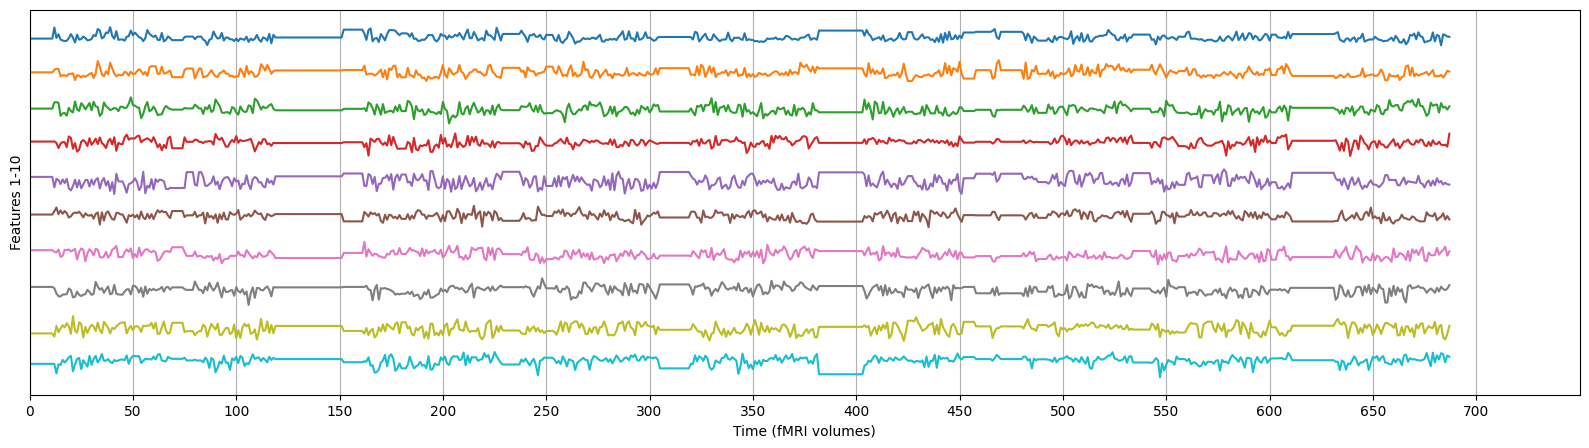

In [10]:
f = figure(figsize=(20, 5))
ax = f.add_subplot(1,1,1)

for ii in range(10):
    # Plot each feature, offset by 5 vertically so they are easier to see
    ax.plot(Rstim[:750,ii] - 5 * ii)

ax.set_xlim(0, 750)
ax.set_yticks([])
ax.set_xticks(range(0, 750, 50))
ax.set_xlabel("Time (fMRI volumes)")
ax.set_ylabel("Features 1-10")
ax.grid()

In [5]:

# plt.figure(figsize=(12, 10))

# for i, (key, values) in enumerate(signal.items(), 1):
#     plt.subplot(5, 1, i)
#     plt.plot(values[:2000], label=key, alpha=0.8)
#     plt.ylabel("Value")
#     plt.legend(loc="upper right")
#     if i == 5:
#         plt.xlabel("Index")

# plt.suptitle("First 5000 values from each layer (stacked)", fontsize=14)
# plt.tight_layout(rect=[0, 0, 1, 0.96])
# # plt.show()

In [6]:
# TODO - downsample the signal to match 